In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
def apply_hann_window_mp3(
    file_path: str, start_sec: float = 1.0, duration_sec: float = 0.05
):
    """Load file .mp3, trích xuất đoạn âm thanh và áp dụng Hann Window để vẽ biểu đồ so sánh.

    Parameters:
    - file_path: Đường dẫn tới file .mp3
    - start_sec: Thời điểm bắt đầu cắt mẫu (giây)
    - duration_sec: Độ dài đoạn âm thanh lấy mẫu (giây, nên để ngắn 0.02 - 0.1s để quan sát rõ sóng)
    """
    # 1. Load file MP3 và lấy mẫu tín hiệu
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # 2. Trích xuất một khung tín hiệu (frame/segment)
    start_sample = int(start_sec * sr)
    num_samples = int(duration_sec * sr)
    signal = y[start_sample : start_sample + num_samples]

    # Trục thời gian tính bằng mili giây (ms)
    t = np.linspace(0, duration_sec * 1000, len(signal))

    # 3. Tạo cửa sổ Hann và nhân với tín hiệu gốc
    hann_window = np.hanning(len(signal))
    windowed_signal = signal * hann_window

    # 4. Trực quan hóa biểu đồ
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # Tín hiệu âm thanh gốc
    axs[0].plot(t, signal, color="#1f77b4", linewidth=1.2)
    axs[0].set_title("1. Tín hiệu âm thanh gốc (Trước khi nhân Cửa sổ)")
    axs[0].set_ylabel("Biên độ")
    axs[0].grid(True, linestyle=":", alpha=0.6)

    # Cửa sổ Hann (Hann Window)
    axs[1].plot(t, hann_window, color="#2ca02c", linestyle="--", linewidth=2)
    axs[1].set_title("2. Hàm Cửa sổ Hann (Hann Window Shape)")
    axs[1].set_ylabel("Hệ số (0 đến 1)")
    axs[1].grid(True, linestyle=":", alpha=0.6)

    # Tín hiệu sau khi áp dụng Hann Window
    axs[2].plot(t, windowed_signal, color="#d62728", linewidth=1.2)
    axs[2].set_title("3. Tín hiệu âm thanh sau khi áp dụng Hann Window")
    axs[2].set_xlabel("Thời gian (ms)")
    axs[2].set_ylabel("Biên độ")
    axs[2].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


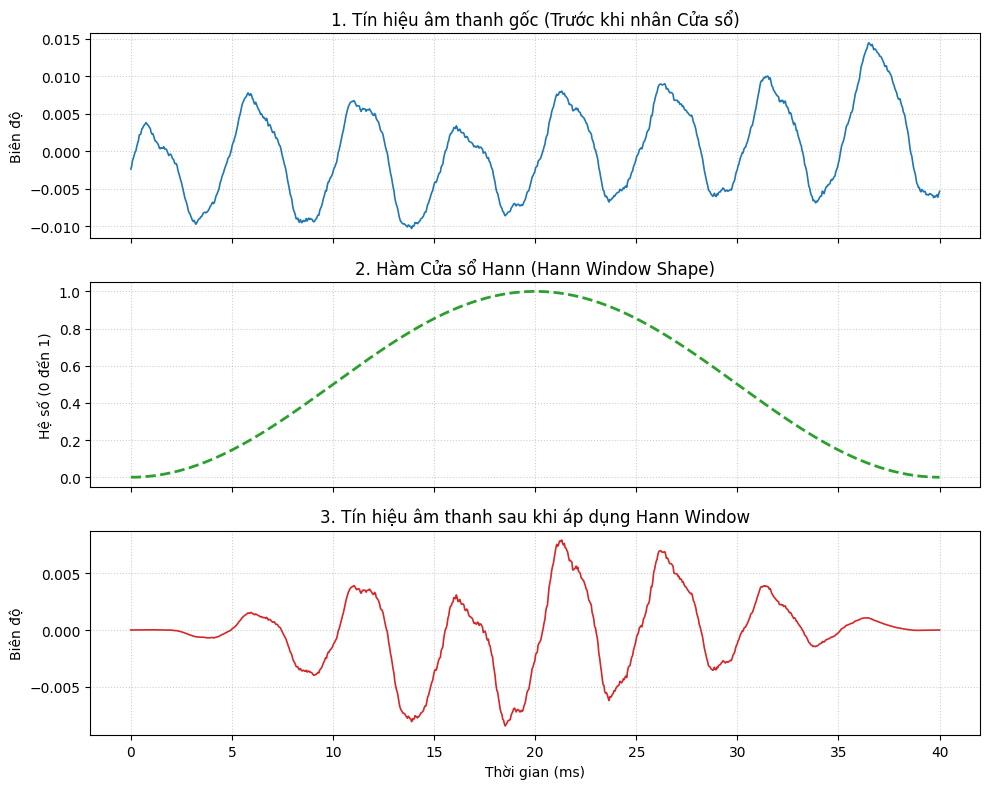

In [2]:
apply_hann_window_mp3(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", 
                        start_sec=2.0, duration_sec=0.04)